In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import copy


In [3]:
rows_to_read = 1000
df_merge = pd.read_csv('../raw_data/train_merge.csv', nrows = rows_to_read)


In [4]:
float_columns = []
int_columns = []
object_columns = []
for a,b in zip(df_merge.columns, list(df_merge.dtypes)):
    if b == 'int64':
        int_columns.append(a)
    elif b=='float64':
        float_columns.append(a)
    else:
        object_columns.append(a)
print(len(float_columns+int_columns))



403


## Measuring Correlation between Numeric Columns and Fraud

In [5]:
n_rows_total = 0
n_rows = {c:0 for c in int_columns+float_columns}
mins = {c:float('inf') for c in int_columns+float_columns}
maxs = {c:-float('inf') for c in int_columns+float_columns}
sums = {c:0 for c in int_columns+float_columns}
square_sums = {c:0 for c in int_columns+float_columns}
covariance_sums = {c:0 for c in int_columns+float_columns}
square_sums_red = {c:0 for c in int_columns+float_columns}
fraud_counts = {c:0 for c in int_columns+float_columns}

print_st = True
for chunk in pd.read_csv('../raw_data/train_merge.csv', chunksize = 10000):
    n_rows_total += chunk.shape[0]
    for c in int_columns+float_columns:
        vals = chunk[['isFraud',c]].dropna().to_numpy()
        rho = vals[:,0]
        vals = vals[:,1]
        if len(vals)==0:
            continue
        mins[c] = min(mins[c],vals.min())
        maxs[c] = max(maxs[c], vals.max())
        sums[c] += vals.sum()
        square_sums[c] = square_sums[c] + np.float128(np.sum(vals**2))
        n_rows[c] += np.float32(len(vals))
        covariance_sums[c] += np.dot(rho,vals)
        fraud_counts[c] += rho.sum()

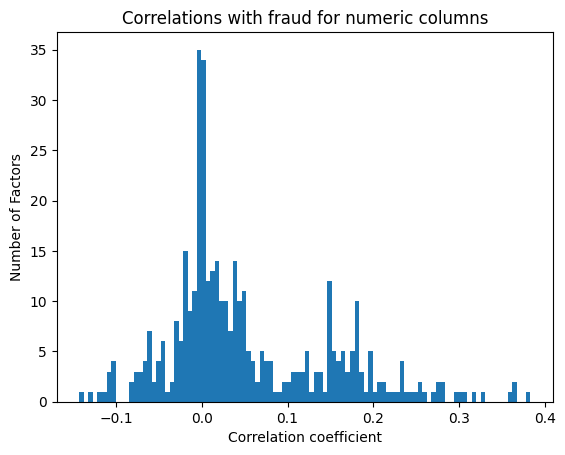

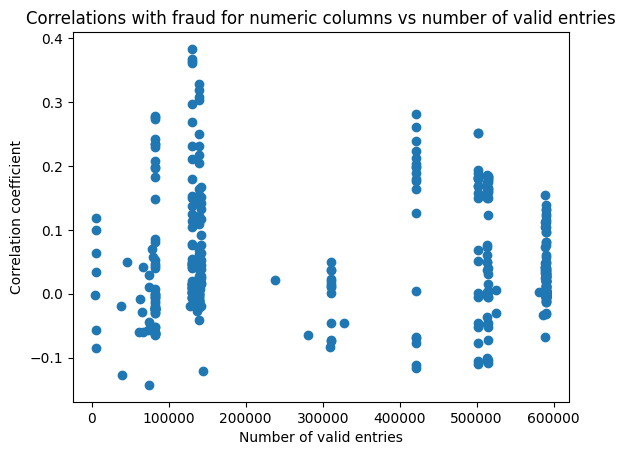

In [6]:
numeric_columns = int_columns + float_columns
correlations = dict()
all_fraud_nans = []
no_fraud_nans = []
const_values = []

for c in numeric_columns[2:]:
    erho = fraud_counts[c]/n_rows[c]
    evalue = sums[c]/n_rows[c]
    cross_term = covariance_sums[c]/n_rows[c]
    var_rho = erho*(1-erho)
    var_val = square_sums[c]/n_rows[c] - evalue**2
    if var_rho<0:
        print(erho, c, fraud_counts[c], n_rows[c])

    corr = (cross_term-erho*evalue)/np.sqrt(var_val*var_rho)
    if np.isnan(corr):
        if erho == 0:
            no_fraud_nans.append(c)
        elif erho == 1:
            all_fraud_nans.append(c)
        else:
            const_values.append(c)
    else:
        correlations[c] = [corr,n_rows[c]]
    

corrs = list(correlations.items())
corrs.sort(key = lambda x: -abs(x[1][0]))

plt.hist([c[1][0] for c in corrs], bins = 100)
plt.title('Correlations with fraud for numeric columns')
plt.xlabel('Correlation coefficient')
plt.ylabel('Number of Factors')
plt.show()

plt.scatter([c[1][1] for c in corrs], [c[1][0] for c in corrs])
plt.title('Correlations with fraud for numeric columns vs number of valid entries')
plt.ylabel('Correlation coefficient')
plt.xlabel('Number of valid entries')
plt.show()

Let's cut down on the data that we will use. First, we'll not consider any column that has fewer than 100,000 entries. Then we'll ignore all entries whose correlation with fraud is between $-0.05$ and $0.05$. 

We will also keep TransactionID as an index, TransactionDT as perhaps valuable time information, and TransactionAmt to compute lossed revenue.

In [30]:
numeric_columns_keep = ['isFraud', 'TransactionID', 'TransactionAmt, TransactoinDT']
for col_name, [corr_coef, count] in corrs:
    if abs(corr_coef)>0.05 and count>=100000 and col_name not in numeric_columns_keep:
        numeric_columns_keep.append(col_name)


print(len(numeric_columns_keep))

143


In [19]:
df_merge.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [8]:
counters = {c:dict() for c in object_columns}

for chunk in pd.read_csv('../raw_data/train_merge.csv', chunksize = 10000):

    n_rows_total += chunk.shape[0]
    for c in object_columns:
        counter_update = counters[c]
        vals = chunk[['isFraud',c]].dropna().groupby(c).agg(count = (c, 'count'),total_sum = ('isFraud','sum')).reset_index().to_numpy()
        m = vals.shape[0]
        for i in range(m):
            name = vals[i,0]
            total = vals[i,1:]
            if name in counter_update:
                counter_update[name] += total
            else:
                counter_update[name] = copy.copy(total)
        counters[c] = counter_update


        
        


In [9]:
for c,di in counters.items():
    if sum([val[0] for val in di.values()])>=n_rows_total/4:
        names = list()
        x_vals = list()
        y_vals = list()
        for name, counts in di.items():
            x_vals.append(counts[0])
            y_vals.append(counts[1]/counts[0])
            names.append(name)

        new_df = pd.DataFrame(
            {'Type':names, 
             'Counts': x_vals,
             'Fraud Rate':y_vals}
        )
        fig = px.scatter(new_df, x = 'Counts', y = 'Fraud Rate', hover_data = ['Type'], title = c)
        fig.show()
        

In [10]:
export_to_json = {c:list(val.keys()) for c, val in counters.items()}

for c,val in export_to_json.items():
    if len(val)>=5:
        print(c, len(val))


ProductCD 5
P_emaildomain 59
R_emaildomain 60
id_30 75
id_31 130
id_33 260
DeviceInfo 1786


In [11]:
import tqdm 
device_map = dict()
li = set(copy.copy(export_to_json['DeviceInfo']))
print(f'{len(li)} many total distinct device types')
to_remove = set()
for c in tqdm.tqdm(li):
    to_remove |= {c}
    if c[:7].lower() == 'samsung' or c[:2] in ["SM", 'GT','SG']or c[:3] in ['A96', 'M10']:
        device_map[c] = 'Samsung'
    elif c[:7].lower() == 'android':
        device_map[c] = 'Android'
    elif c[:2].lower() in ['lg', 'vs', 'vk']:
        device_map[c] = 'LG'
    elif c[:4].lower() == 'asus':
        device_map[c] = 'Asus'
    elif c[:6].lower() == 'huawei' or c[:3] == 'rne' or 'huawei' in c.lower():
        device_map[c] = 'Huawei'
    elif c[:5].lower() == 'pixel':
        device_map[c] = 'Google'
    elif c[:4].lower() == 'moto' or c[:2]=='XT':
        device_map[c] = 'Motorola'
    elif c[:6].lower() == 'lenovo':
        device_map[c] = 'Lenovo'
    elif c[:3].lower() == 'htc':
        device_map[c] = 'HTC'
    elif c[:2].lower() in ['m4'] + [a+b for a in ['e','d','f','g'] for b in [str(j) for j in [2,3,5,6]]] or c[:3] in ['F83', 'F81', 'G81', 'G83']:
        device_map[c] = 'Sony'
    elif c[:5] in ['MacOS', 'iPhon', 'iOS D']:
        device_map[c] = 'Apple'
    elif c[:3] == 'ZTE' or c[:5]=='Blade' or c[:2] in ['Z8','Z9']:
        device_map[c] = 'ZTE'
    elif c[:3]=="Win" or c[:9].lower()=='microsoft':
        device_map[c] = 'Microsoft'
    elif c[:5].lower() == 'redmi':
        device_map[c] = 'Redmi'
    elif c[:5].lower() == 'nexus':
        device_map[c] = 'Nexus'
    elif c[:5].lower() == 'nokia' or c[:2].lower()=='ta':
        device_map[c] = 'Nokia'
    elif c[:4].lower() == 'very':
        device_map[c] = 'verykool'
    elif c[:2].lower()=='rv':
        device_map[c] = 'rv'
    elif c[:7].lower() == 'alcatel' or c[:2] in [str(j) for j in [40,50,60,70,90]] or c[:3]=='ONE':
        device_map[c] = 'Alcatel'
    elif c[:3] == 'STV':
        device_map[c] = 'Blackberry'
    else:
        device_map[c] = 'Other'
        to_remove.remove(c)
    

li = list(li-to_remove)
print(f'{len(li)} many device types listed as Other')


1786 many total distinct device types


100%|██████████| 1786/1786 [00:00<00:00, 267842.78it/s]

389 many device types listed as Other


In [12]:
import tqdm 
os_map = dict()
li = set(copy.copy(export_to_json['id_33']))
print(f'{len(li)} many total distinct device types')
to_remove = set()

for c in li:
    to_remove |= {c}
    if c[:3] == 'Mac':
        os_map[c] = 'Mac'
    elif c[:3] == 'Win':
        os_map[c] = 'Windows'
    elif c[:7] == 'Android':
        os_map[c] = 'Android'
    elif c[:3] == 'iOS':
        os_map[c] = 'iOS'
    else:
        to_remove.remove(c)

li = li-to_remove
li = list(li)
li.sort()
for c in li:
    print(c)

260 many total distinct device types
0x0
1023x767
1023x768
1024x552
1024x600
1024x640
1024x767
1024x768
1024x819
1025x768
1062x630
1092x614
1093x615
1120x700
1136x640
1138x640
1152x648
1152x720
1152x864
1184x720
1188x720
1200x675
1200x720
1229x691
1232x800
1239x697
1264x924
1272x960
1279x1023
1279x1024
1280x1023
1280x1024
1280x1025
1280x600
1280x620
1280x712
1280x720
1280x732
1280x740
1280x768
1280x800
1280x900
1280x960
1281x720
1281x721
1281x800
1281x801
1296x774
1334x750
1344x756
1344x840
1356x900
1359x768
1360x767
1360x768
1364x768
1365x767
1365x768
1366x1024
1366x767
1366x768
1368x768
1371x857
1400x1050
1400x900
1408x792
1408x880
1422x889
1439x809
1439x899
1439x900
1440x720
1440x759
1440x800
1440x803
1440x810
1440x899
1440x900
1440x960
1441x901
1480x720
1496x844
1502x844
1502x845
1511x944
1512x945
1536x1152
1536x864
1536x960
1584x990
1596x710
1599x899
1599x900
1600x1000
1600x1024
1600x1200
1600x837
1600x899
1600x900
1624x1080
1638x922
1658x946
1679x1049
1680x1049
1680x1050
1680x105

In [32]:
import tqdm 
os_map = dict()
li = set(copy.copy(export_to_json['id_30']))
print(f'{len(li)} many total distinct device types')
to_remove = set()

for c in li:
    to_remove |= {c}
    if c[:3] == 'Mac':
        os_map[c] = 'Mac'
    elif c[:3] == 'Win':
        os_map[c] = 'Windows'
    elif c[:7] == 'Android':
        os_map[c] = 'Android'
    elif c[:3] == 'iOS':
        os_map[c] = 'iOS'
    else:
        os_map[c] = c

75 many total distinct device types
